# <center>        **Introduction to Data Science (S2-22_DSECLZG532)-ASSIGNMENT**</center>

## Group No: 053

## Group Member Names:
1. Mohammed Mudassirullah Sheriff
2. Suraj Kumar R C
3. Bhavvya R Sureka
4. Shaurya Mehta

# 1. Business Understanding

Students are expected to identify an analytical problem of your choice. You have to detail the Business Understanding part of your problem under this heading which basically addresses the following questions.

   1. What is the business problem that you are trying to solve?
   2. What data do you need to answer the above problem?
   3. What are the different sources of data?
   4. What kind of analytics task are you performing?

Score: 1 Mark in total (0.25 mark each)

# 2. Data Acquisition

For the problem identified , find an appropriate data set (Your data set must
be unique with minimum **20 features and 10k rows**) from any public data source.

---



## 2.1 Download the data directly



In [62]:
##---------Type the code below this line-----------------

# Install Kaggle to download dataset from kaggle.com
! pip install kaggle

import os
os.environ['KAGGLE_USERNAME'] = 'mudassirsheriff'
os.environ['KAGGLE_KEY'] = 'f7892b671c9df4a3f144bce6aa5c0675'

# Authentication and dataset download from kaggle using Kaggle API
import kaggle as kg

kg.api.authenticate()

kg.api.dataset_download_files(dataset="abdallahwagih/telco-customer-churn", path="./dataset", unzip=True)

from huggingface_hub import hf_hub_download

REPO_ID = "aai510-group1/telco-customer-churn"
FILE_NAME = "train.csv"
hf_hub_download(repo_id=REPO_ID, filename=FILE_NAME, repo_type="dataset", local_dir="./dataset")

# Set the dataset path for further processing
kaggle_dataset_path = os.path.join(os.path.abspath(""),"dataset\Telco_customer_churn.xlsx")
hf_dataset_path = os.path.join(os.path.abspath(""),"dataset\\train.csv")

Dataset URL: https://www.kaggle.com/datasets/abdallahwagih/telco-customer-churn


## 2.2 Code for converting the above downloaded data into a dataframe

In [63]:
##---------Type the code below this line------------------##

! pip install pandas 
! pip install openpyxl

import pandas as pd

kaggle_df = pd.read_excel(kaggle_dataset_path)

huggingface_df = pd.read_csv(hf_dataset_path)
huggingface_renaming = {
    "Customer Status": "Churn Label",
    "Churn": "Churn Value",
    "Total Charges": "Total Charges",
    "Zip Code": "Zip Code",
    "City": "City",
    "Contract": "Contract",
    "Country": "Country",
    "CLTV": "CLTV",
    "Customer ID": "CustomerID", 
    "Tenure in Months": "Tenure Months", 
    "Device Protection Plan": "Device Protection", 
    "Monthly Charge": "Monthly Charges",
    "Premium Tech Support": "Tech Support",
    "Internet Service": "Internet Service Value",
    "Internet Type": "Internet Service"
}

huggingface_df.rename(columns=huggingface_renaming, inplace=True)

# Identifying common columns for merging
common_columns = list(set(kaggle_df.columns) & set(huggingface_df.columns))


# Check data types of common columns in both datasets
kaggle_dtypes = kaggle_df[common_columns].dtypes
huggingface_dtypes = huggingface_df[common_columns].dtypes

# Compare data types
dtype_comparison = pd.DataFrame({"Kaggle": kaggle_dtypes, "HuggingFace": huggingface_dtypes})
dtype_comparison[dtype_comparison["Kaggle"] != dtype_comparison["HuggingFace"]]

# Convert Hugging Face dataset columns to match Kaggle dataset types
for col in dtype_comparison.index:
    if kaggle_dtypes[col] == "object":
        huggingface_df[col] = huggingface_df[col].astype(str)
    else:
        huggingface_df[col] = pd.to_numeric(huggingface_df[col], errors='coerce')

# Retry merging with corrected data types
df = pd.merge(kaggle_df, huggingface_df, on=common_columns, how="outer")



## 2.3 Confirm the data has been correctly by displaying the first 5 and last 5 records.

In [64]:
##---------Type the code below this line------------------##

# Displaying the first 5 records
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Quarter,Referred a Friend,Satisfaction Score,Streaming Music,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data
0,8660-BUETV,NaN,United States,California,Riverside,92501,"33.994676, -117.372498",33.994676,-117.372498,Female,...,Q3,0.0,5.0,0.0,10.0,104.67,0.0,262.72,0.0,0.0
1,4102-HLENU,NaN,United States,California,Auburn,95603,"38.912881, -121.082766",38.912881,-121.082766,Female,...,Q3,1.0,3.0,0.0,0.0,1529.61,0.0,5852.46,0.0,1.0
2,7041-TXQJH,NaN,United States,California,Goodyears Bar,95944,"39.564113, -120.868836",39.564113,-120.868836,Female,...,Q3,0.0,5.0,1.0,0.0,0.00,0.0,1478.85,0.0,1.0
3,2782-LFZVW,NaN,United States,California,Costa Mesa,92627,"33.645672, -117.922613",33.645672,-117.922613,Female,...,Q3,0.0,4.0,1.0,70.0,270.27,0.0,941.87,0.0,0.0
4,5844-QVTAT,NaN,United States,California,Irvine,92620,"33.716136, -117.752574",33.716136,-117.752574,Female,...,Q3,1.0,4.0,0.0,0.0,290.07,0.0,2245.47,1.0,1.0


In [65]:

# Displaying the last 5 records
df.tail()



,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Quarter,Referred a Friend,Satisfaction Score,Streaming Music,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data
11263,6776-TLWOI,NaN,United States,California,Livingston,95334,"37.361987, -120.748394",37.361987,-120.748394,Male,...,Q3,0.0,1.0,0.0,0.0,96.03,0.0,160.58,1.0,0.0
11264,6598-RFFVI,NaN,United States,California,San Bernardino,92405,"34.142747, -117.300864",34.142747,-117.300864,Male,...,Q3,0.0,3.0,0.0,0.0,31.58,0.0,59.88,0.0,0.0
11265,8515-OCTJS,NaN,United States,California,Lemoore,93245,"36.303666, -119.825657",36.303666,-119.825657,Female,...,Q3,0.0,3.0,0.0,0.0,493.75,0.0,1185.85,0.0,0.0
11266,7989-CHGTL,NaN,United States,California,San Diego,92122,"32.85723, -117.209783",32.857230,-117.209774,Male,...,Q3,0.0,1.0,0.0,0.0,14.17,0.0,33.77,0.0,0.0
11267,6861-OKBCE,NaN,United States,California,Seal Beach,90740,"33.75462, -118.071128",33.754620,-118.071128,Female,...,Q3,0.0,2.0,0.0,0.0,363.66,0.0,585.01,0.0,0.0


## 2.4 Display the column headings, statistical information, description and statistical summary of the data.

In [66]:
##---------Type the code below this line------------------##
df.columns


Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason', 'Age', 'Avg Monthly GB Download',
       'Avg Monthly Long Distance Charges', 'Churn Category',
       'Internet Service Value', 'Married', 'Number of Dependents',
       'Number of Referrals', 'Offer', 'Population', 'Quarter',
       'Referred a Friend', 'Satisfaction Score', 'Streaming Music',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Refunds', 'Total Revenue', 'Under 30', 'Unlimited Data'],
      dtype='object

In [67]:
#Statistical information like data types, counts etc
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11268 entries, 0 to 11267
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   CustomerID                         11268 non-null  object 
 1   Count                              7043 non-null   float64
 2   Country                            11268 non-null  object 
 3   State                              11268 non-null  object 
 4   City                               11268 non-null  object 
 5   Zip Code                           11268 non-null  int64  
 6   Lat Long                           11268 non-null  object 
 7   Latitude                           11268 non-null  float64
 8   Longitude                          11268 non-null  float64
 9   Gender                             11268 non-null  object 
 10  Senior Citizen                     11268 non-null  object 
 11  Partner                            11268 non-null  obj

In [68]:
#Description and Statistical summary
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV,Age,...,Population,Referred a Friend,Satisfaction Score,Streaming Music,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data
count,7043.0,11268.000000,11268.000000,11268.000000,11268.000000,11268.000000,11268.000000,11268.000000,11268.000000,4225.000000,...,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000,4225.000000
mean,1.0,93510.689031,36.254257,-119.787371,32.487664,64.815974,0.265353,58.542599,4403.841143,46.451124,...,22008.756686,0.459882,3.242367,0.349586,6.965680,754.719141,1.953846,3065.809082,0.200000,0.677870
std,0.0,1864.847656,2.461655,2.156416,24.581949,30.027400,0.441541,21.403047,1178.358249,16.731518,...,20965.262169,0.498447,1.200716,0.476896,25.250169,854.909725,7.814374,2884.817379,0.400047,0.467348
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000,19.000000,...,11.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,21.360000,0.000000,0.000000
25%,1.0,92102.000000,34.018354,-121.805845,9.000000,35.787500,0.000000,40.000000,3475.000000,32.000000,...,2346.000000,0.000000,3.000000,0.000000,0.000000,67.680000,0.000000,592.750000,0.000000,0.000000
50%,1.0,93541.000000,36.303793,-119.710008,29.000000,70.300000,0.000000,61.000000,4529.000000,46.000000,...,17554.000000,0.000000,3.000000,0.000000,0.000000,396.640000,0.000000,2151.470000,0.000000,1.000000
75%,1.0,95346.000000,38.208336,-118.020188,56.000000,89.850000,1.000000,75.000000,5381.000000,60.000000,...,35737.000000,1.000000,4.000000,1.000000,0.000000,1200.000000,0.000000,4845.750000,0.000000,1.000000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000,80.000000,...,105285.000000,1.000000,5.000000,1.000000,150.000000,3564.000000,49.790000,11979.340000,1.000000,1.000000


In [69]:
# Check for columns with null values
df.isna().sum()

CustomerID                               0
Count                                 4225
Country                                  0
State                                    0
City                                     0
Zip Code                                 0
Lat Long                                 0
Latitude                                 0
Longitude                                0
Gender                                   0
Senior Citizen                           0
Partner                                  0
Dependents                               0
Tenure Months                            0
Phone Service                            0
Multiple Lines                           0
Internet Service                         0
Online Security                          0
Online Backup                            0
Device Protection                        0
Tech Support                             0
Streaming TV                             0
Streaming Movies                         0
Contract   

## 2.5 Write your observations from the above.
1. Size of the dataset
2. What type of data attributes are there?
3. Is there any null data that has to be cleaned?

Score: 2 Marks in total (0.25 marks for 2.1, 0.25 marks for 2.2, 0.5 marks for 2.3, 0.25 marks for 2.4, 0.75 marks for 2.5)

# 3. Data Preparation

## 3.1 Check for

* duplicate data
* missing data
* data inconsistencies


In [70]:
##---------Type the code below this line------------------##

# Checking for duplicates
duplicates = df.duplicated().sum()

if duplicates > 0:
    print(f"Duplicates rows available: {duplicates}")
else:
    print("No Duplicates in the datatset")

# Checking for missing Data
missing_values = df.isnull().sum() 
missing_percentage = (missing_values / len(df)) * 100
# Filter columns with missing data
missing_summary = pd.DataFrame({"Missing Values": missing_values, "Percentage": missing_percentage}) 
missing_summary = missing_summary[missing_summary["Missing Values"] > 0].sort_values(by="Percentage", ascending=False)

print(missing_summary)

No Duplicates in the datatset
                                   Missing Values  Percentage
Churn Category                              10147   90.051473
Offer                                        9367   83.129215
Avg Monthly GB Download                      7043   62.504437
Avg Monthly Long Distance Charges            7043   62.504437
Internet Service Value                       7043   62.504437
Age                                          7043   62.504437
Satisfaction Score                           7043   62.504437
Streaming Music                              7043   62.504437
Number of Dependents                         7043   62.504437
Married                                      7043   62.504437
Number of Referrals                          7043   62.504437
Population                                   7043   62.504437
Quarter                                      7043   62.504437
Referred a Friend                            7043   62.504437
Total Refunds                           

## 3.2 Apply techiniques
* to remove duplicate data
* to impute or remove missing data
* to remove data inconsistencies


In [71]:
##---------Type the code below this line------------------##

# Handling missing data
    # Define threshold for dropping columns (e.g., >60% missing values)
threshold = 60
cols_to_drop = missing_summary[missing_summary["Percentage"] > threshold].index

# Drop these columns
df_cleaned = df.drop(columns=cols_to_drop)

# Fill missing numerical columns with median values
num_cols = df_cleaned.select_dtypes(include=["number"]).columns
df_cleaned[num_cols] = df_cleaned[num_cols].fillna(df_cleaned[num_cols].median())

# Fill missing categorical columns with mode (most frequent value)
cat_cols = df_cleaned.select_dtypes(include=["object"]).columns

# Standardizing categorical values (e.g., Yes/No, trimming whitespace)
for col in cat_cols:
    df_cleaned[col] = df_cleaned[col].astype(str).str.strip().str.lower()

# Handling Data inconsistencies
cat_value_counts = {col: df_cleaned[col].unique()[:10] for col in cat_cols}  # Show first 10 unique values per column
df_cleaned[cat_cols] = df_cleaned[cat_cols].fillna(df_cleaned[cat_cols].mode().iloc[0])

# Verify remaining missing values
print(f"After Data cleaning, the number of missing values")
df_cleaned.isnull().sum()



After Data cleaning, the number of missing values


CustomerID           0
Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
Churn Reason         0
dtype: int64

## 3.3 Encode categorical data

In [72]:
##---------Type the code below this line------------------##
# Standardizing binary categorical columns (yes/no instead of 1/0)
binary_cols = [
    "Senior Citizen", "Partner", "Dependents", "Phone Service", "Paperless Billing"
]

for col in binary_cols:
    df_cleaned[col] = df_cleaned[col].replace({"1": "yes", "0": "no"})

# Standardizing service-related columns to remove "no internet service" or "no phone service"
service_cols = [
    "Multiple Lines", "Online Security", "Online Backup", "Device Protection", 
    "Tech Support", "Streaming TV", "Streaming Movies"
]

for col in service_cols:
    df_cleaned[col] = df_cleaned[col].replace(
        {"no internet service": "no", "no phone service": "no"}
    )

# Cleaning up Churn Label
df_cleaned["Churn Label"] = df_cleaned["Churn Label"].replace({"nan": None}).fillna("no")
df_cleaned["Churn Label"] = df_cleaned["Churn Label"].replace({"churned": "yes"})
df_cleaned["Churn Label"] = df_cleaned["Churn Label"].replace({"stayed": "no"})
df_cleaned["Churn Label"] = df_cleaned["Churn Label"].replace({"joined": "no"})

# Converting Total Charges to numeric:
df_cleaned["Total Charges"] = pd.to_numeric(df_cleaned["Total Charges"], errors="coerce")

# Verify the cleaned data
print("Data after Encoding categorical columns")
df_cleaned[binary_cols + service_cols + ["Churn Label", "Churn Value"]].head()



Data after Encoding categorical columns


,Senior Citizen,Partner,Dependents,Phone Service,Paperless Billing,Multiple Lines,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Churn Label,Churn Value
0,no,no,no,yes,no,0,0,0,0,0,0,0,no,0
1,no,yes,no,yes,no,1,1,1,1,0,0,0,no,0
2,no,no,no,no,yes,0,0,0,1,0,0,1,no,0
3,no,no,no,yes,yes,1,0,0,0,0,0,1,no,0
4,no,yes,no,yes,yes,0,1,1,1,0,0,0,no,0


In [73]:
##---------Type the code below this line------------------##

## 3.4 Report

Mention and justify the method adopted
* to remove duplicate data, if present
* to impute or remove missing data, if present
* to remove data inconsistencies, if present

OR for textdata
* How many tokens after step 3?
* how may tokens after stop words filtering?

If the any of the above are not present, then also add in the report below.

Score: 2 Marks (based on the dataset you have, the data prepreation you had to do and report typed, marks will be distributed between 3.1, 3.2, 3.3 and 3.4)

In [74]:
##---------Type the code below this line------------------##

In [75]:
##---------Type the code below this line------------------##

## 3.5 Identify the target variables.

* Separate the data from the target such that the dataset is in the form of (X,y) or (Features, Label)

* Discretize / Encode the target variable or perform one-hot encoding on the target or any other as and if required.

* Report the observations

Score: 1 Mark

In [76]:
##---------Type the code below this line------------------##

# Segregating data into features and label
target_column = "Churn Label"

# Encoding the target label
! pip install scikit-learn

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
label_encoder = LabelEncoder()
df_cleaned["Churn Label"] = label_encoder.fit_transform(df_cleaned["Churn Label"])

#Encoding Binary category cols
for col in binary_cols:
    df_cleaned[col] = label_encoder.fit_transform(df_cleaned[col])

categorical_cols = df_cleaned.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].astype(str)
    df_cleaned[col] = LabelEncoder().fit_transform(df_cleaned[col])

print("After encoding category cols")
print(df_cleaned[binary_cols].head())
print(df_cleaned[categorical_cols].head())

X = df_cleaned.drop(columns=[target_column])  # Features
y = df_cleaned[target_column].astype('str')  # Target Label


# Check class distribution
churn_counts = y.value_counts()
churn_percentage = y.value_counts(normalize=True) * 100

print("\nChurn Distribution:\n", churn_counts)
print("\nChurn Percentage:\n", churn_percentage)

After encoding category cols
   Senior Citizen  Partner  Dependents  Phone Service  Paperless Billing
0               0        0           0              1                  0
1               0        1           0              1                  0
2               0        0           0              0                  1
3               0        0           0              1                  1
4               0        1           0              1                  1
   CustomerID  Country  State  City  Lat Long  Gender  Multiple Lines  \
0        6116        0      0   844       382       0               0   
1        2877        0      0    48      1416       0               1   
2        5011        0      0   379      1511       0               0   
3        1910        0      0   223       178       0               1   
4        4132        0      0   457       200       0               0   

   Internet Service  Online Security  Online Backup  Device Protection  \
0                 0 

# 4. Data Exploration using various plots



## 4.1 Scatter plot of each quantitative attribute with the target.

Score: 1 Mark

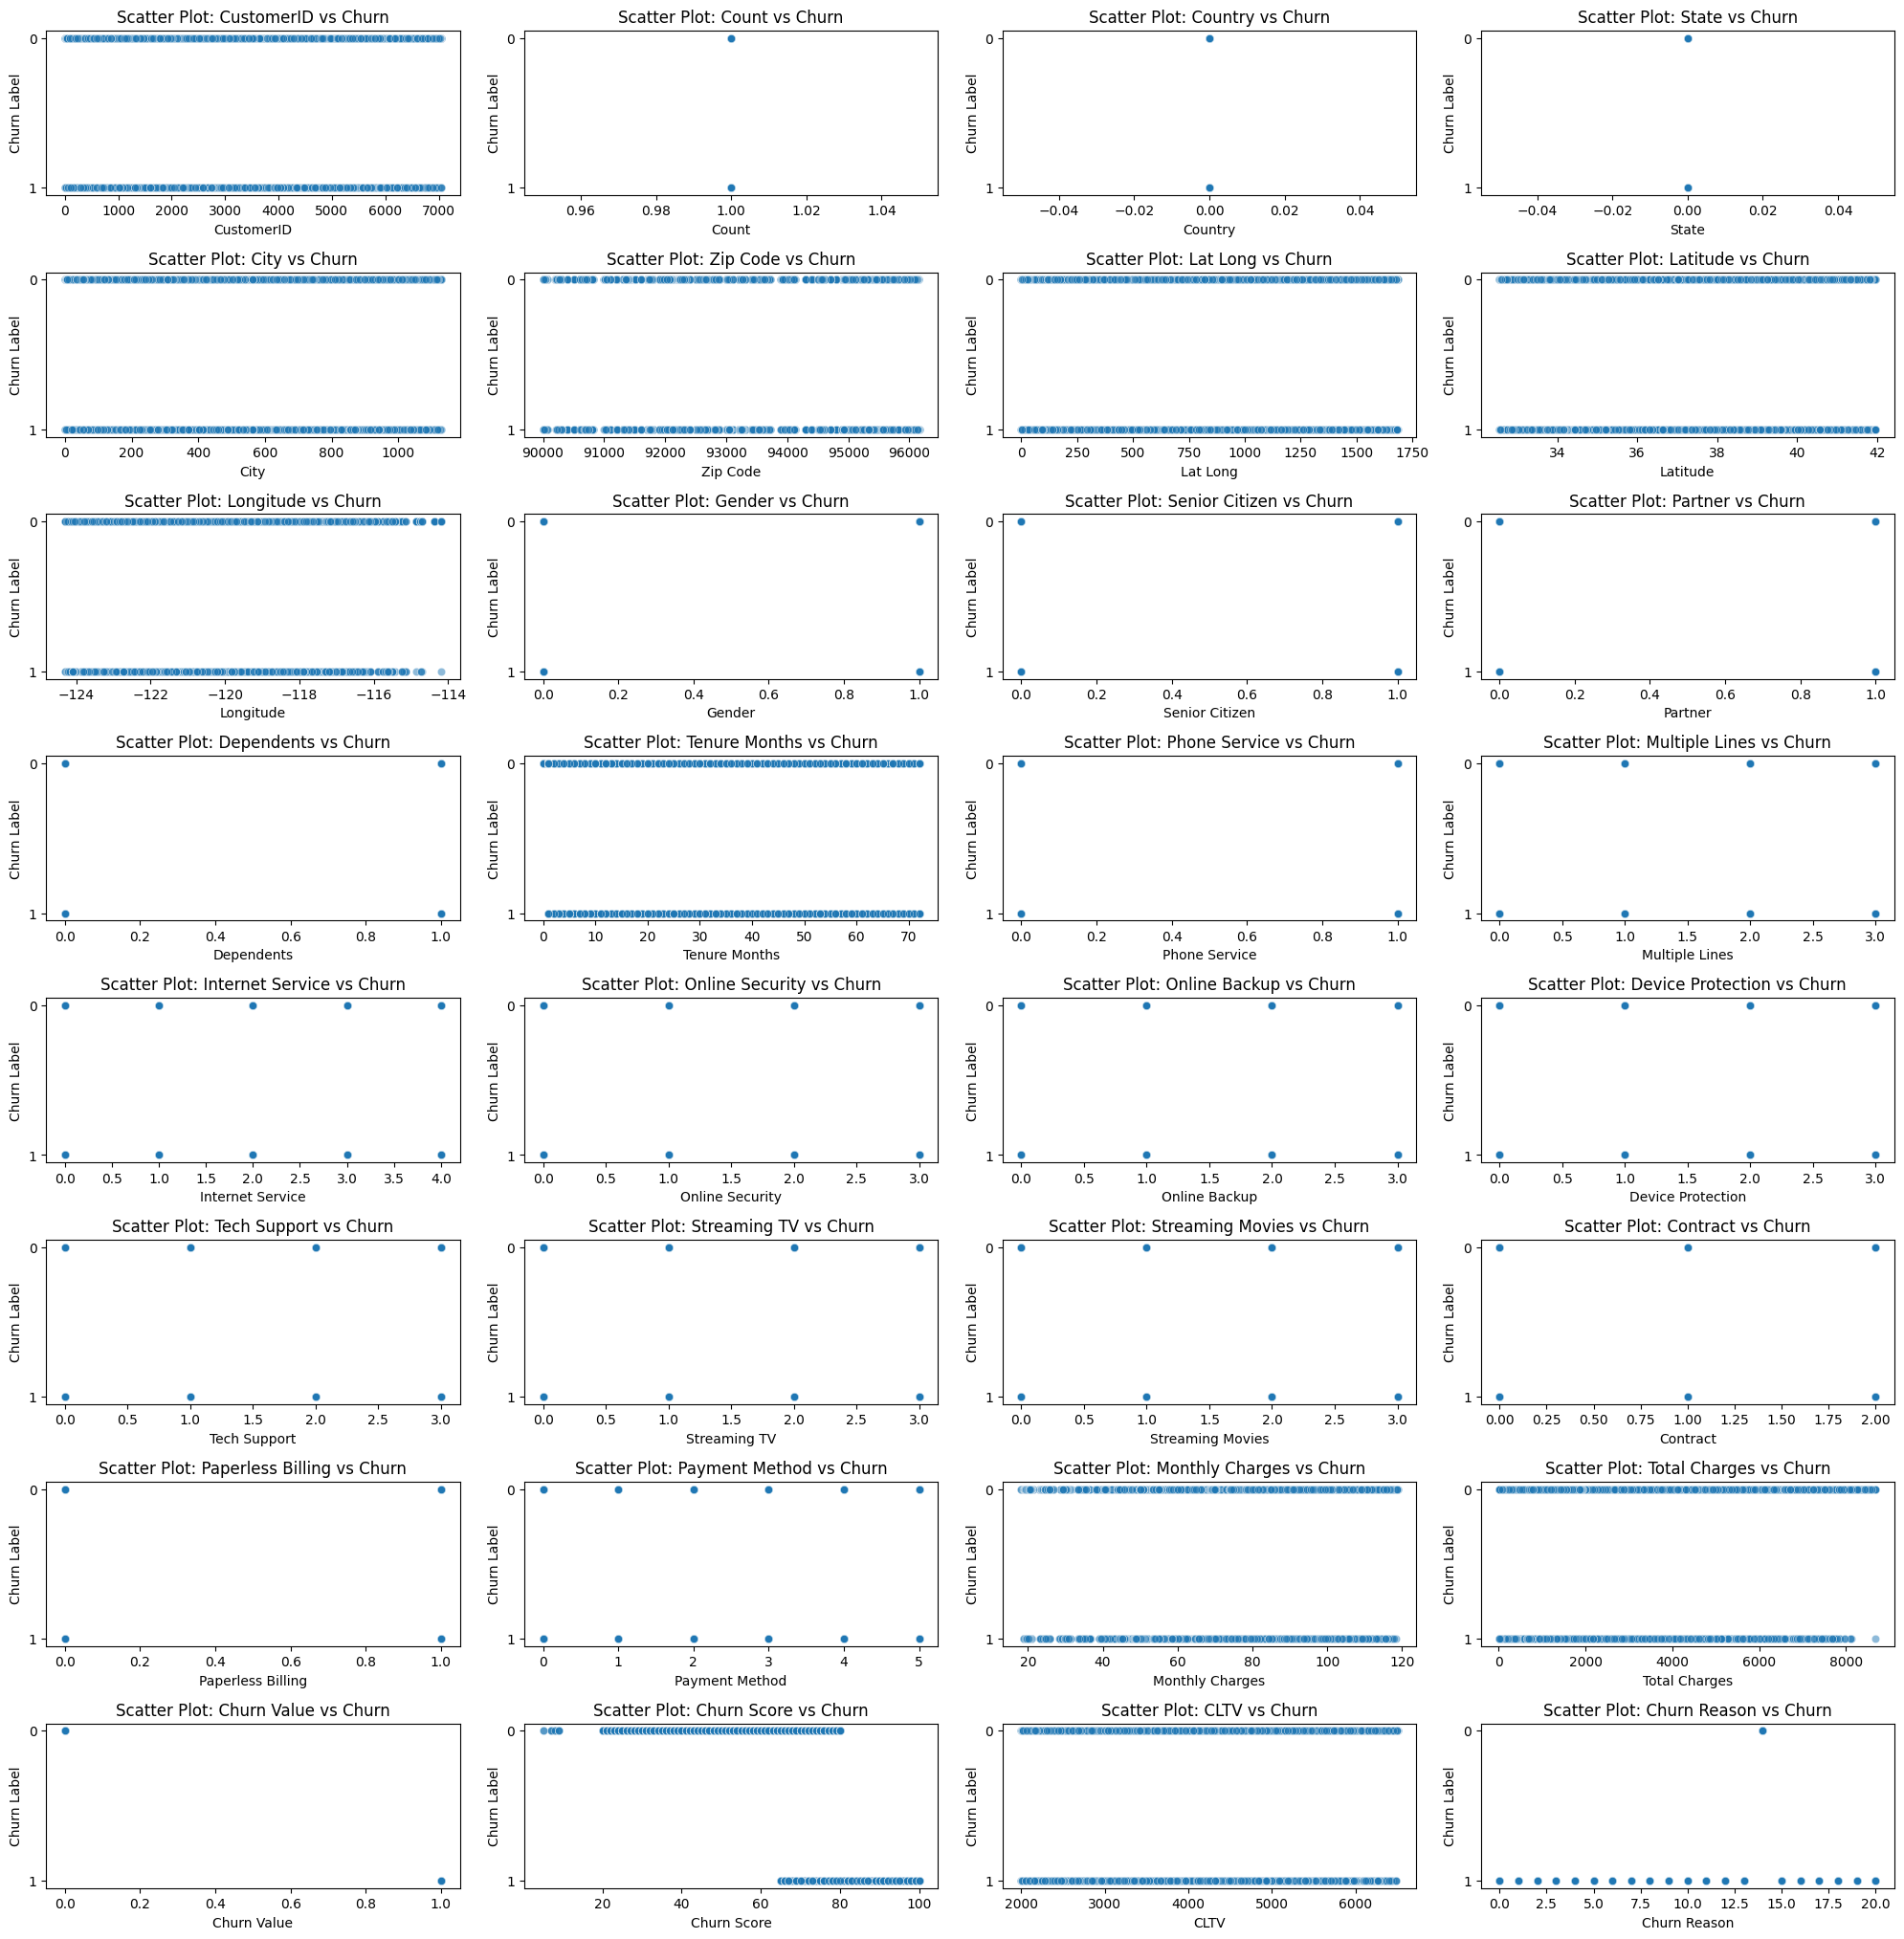

In [77]:
##---------Type the code below this line------------------##
! pip install seaborn
! pip install matplotlib

import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical features
quantitative_cols = X.select_dtypes(include=["int64", "float64"]).columns
plt.figure(figsize=(20, 25))

for i, feature in enumerate(quantitative_cols, 1):
  #plt.figure(figsize=(15, 4))
  plt.subplot(10, 4, i)  # Adjust rows & columns based on feature count
  sns.scatterplot(x=X[feature], y=y, alpha=0.5)
  plt.xlabel(feature)
  plt.ylabel("Churn Label")
  plt.title(f"Scatter Plot: {feature} vs Churn")

plt.tight_layout()
plt.show()

## 4.2 EDA using visuals
* Use (minimum) 2 plots (pair plot, heat map, correlation plot, regression plot...) to identify the optimal set of attributes that can be used for classification.
* Name them, explain why you think they can be helpful in the task and perform the plot as well. Unless proper justification for the choice of plots given, no credit will be awarded.

Score: 2 Marks

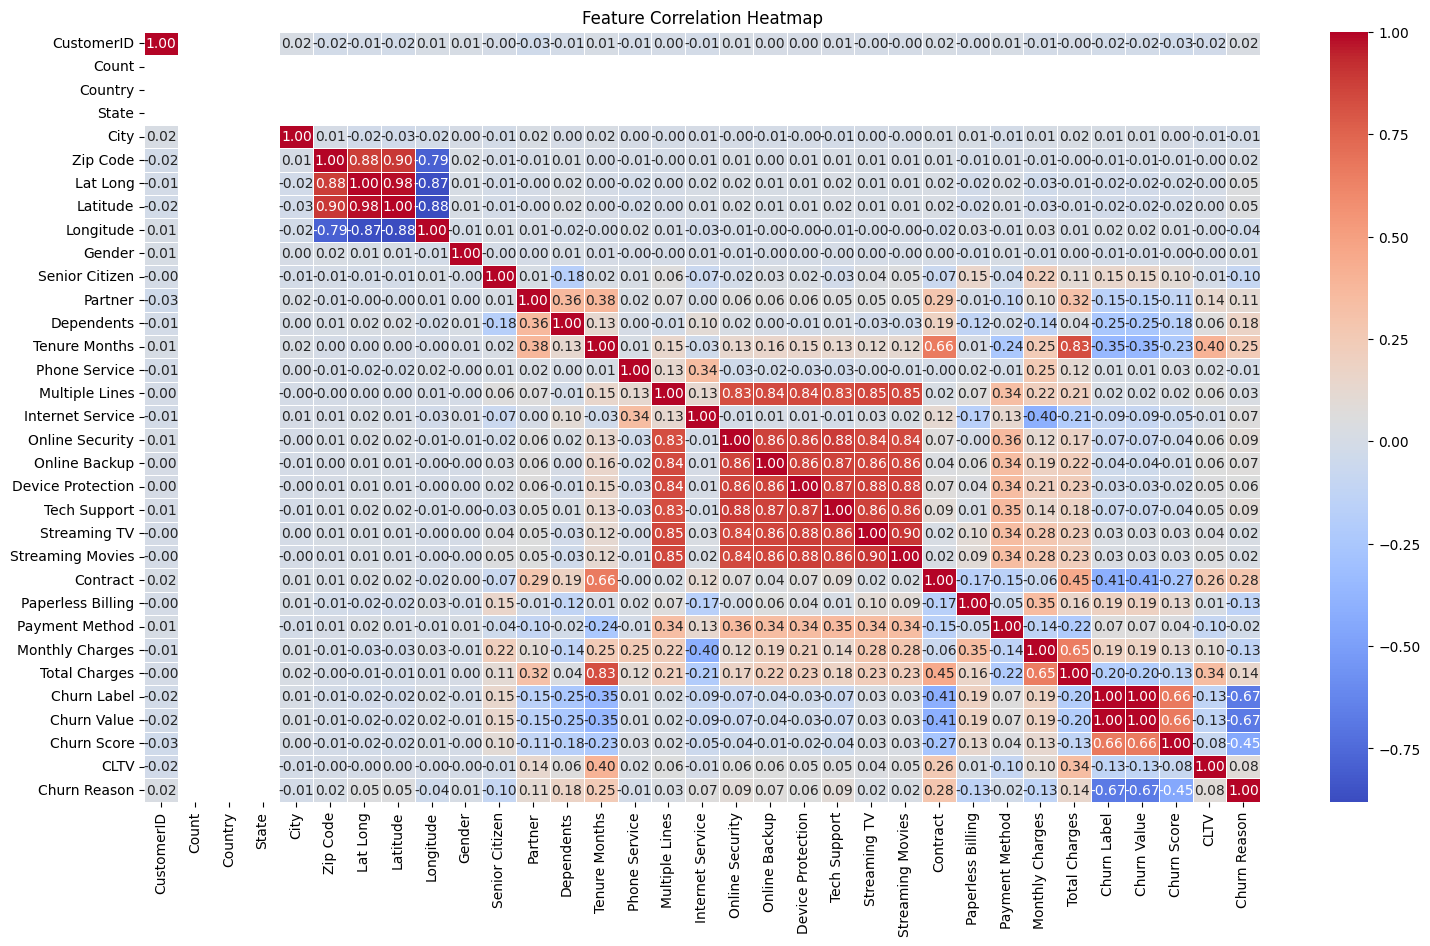

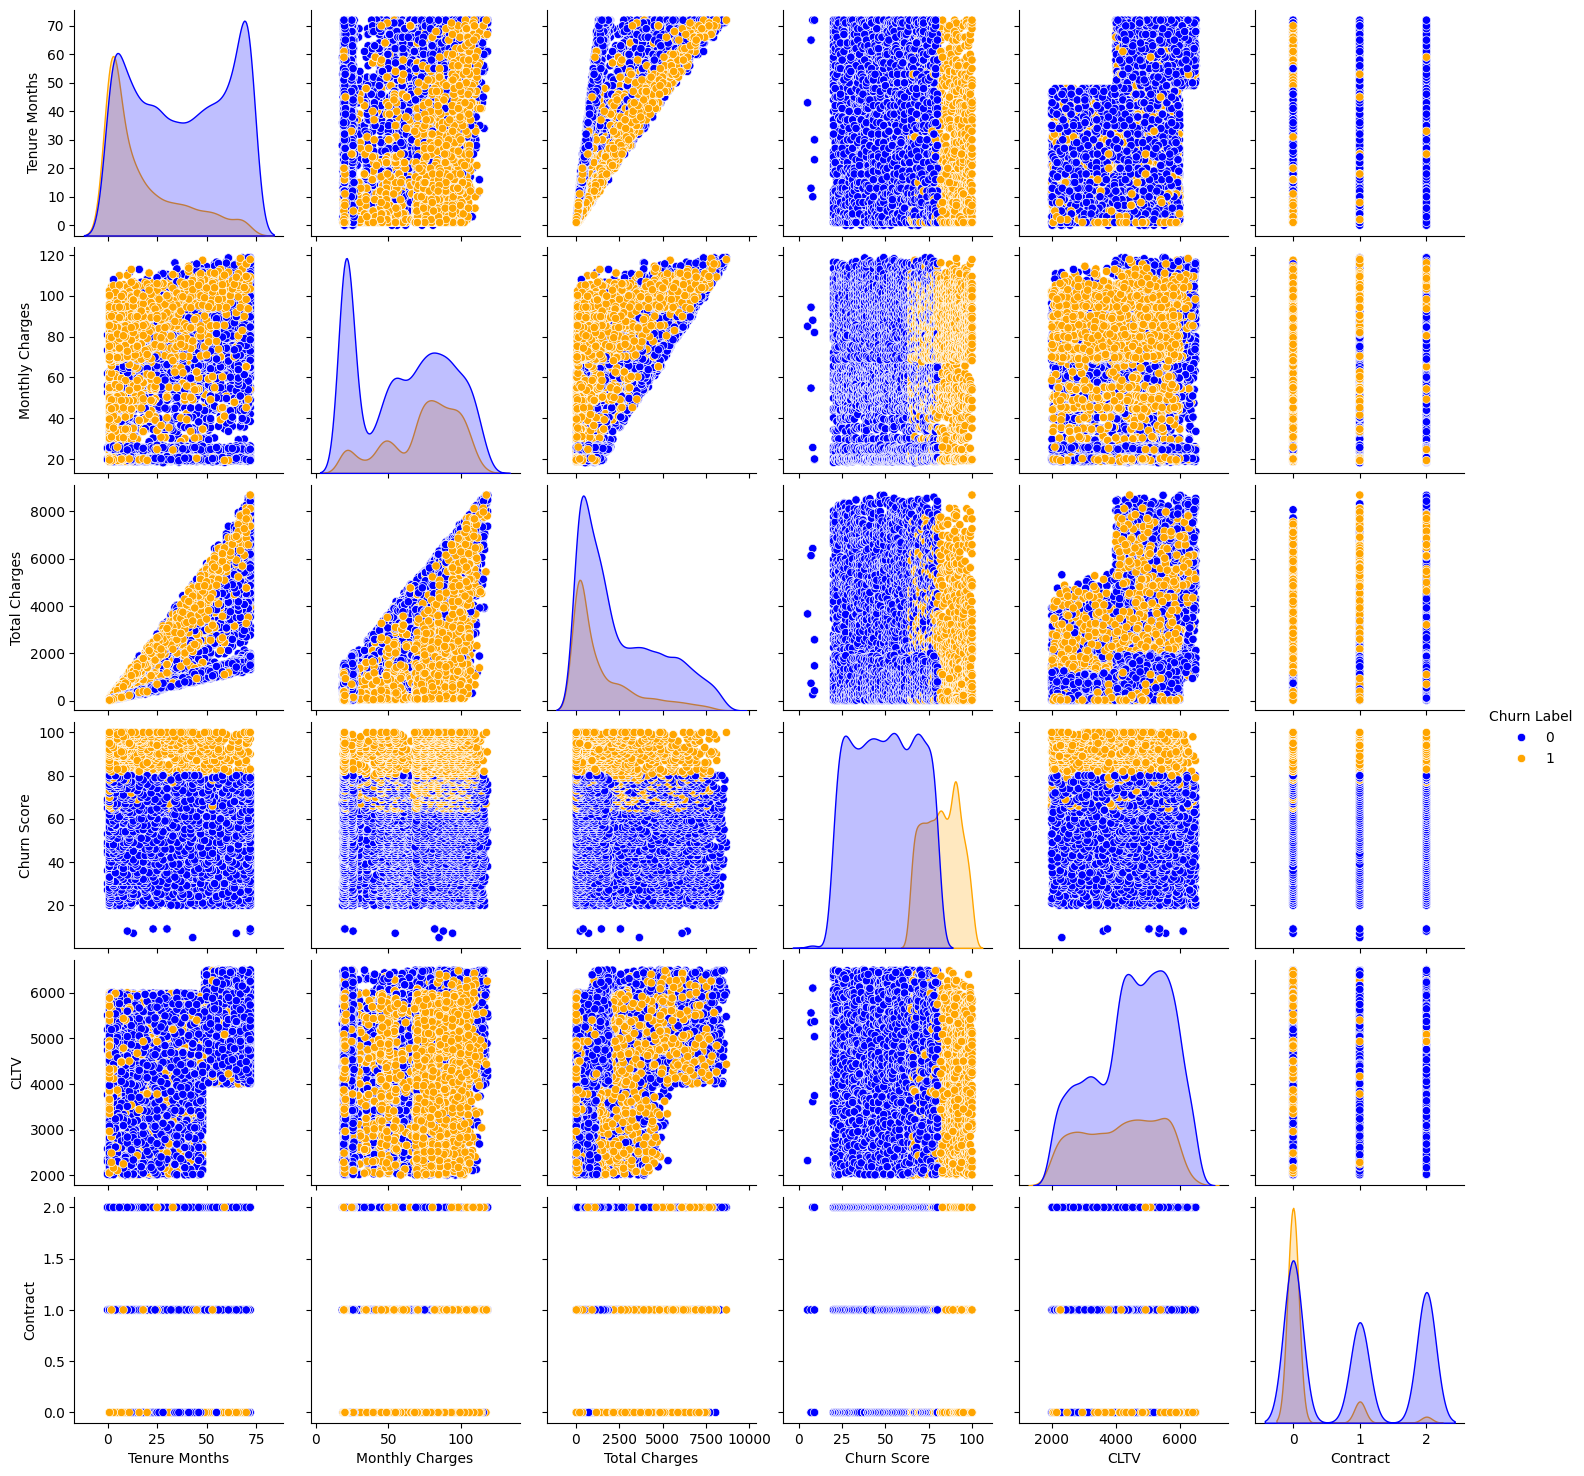

In [78]:
##---------Type the code below this line------------------##
#-------------------- Correlation Heatmap --------------------

plt.figure(figsize=(18, 10))

sns.heatmap(df_cleaned.corr(method="pearson", numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# --- Pair Plaot -----
#--- Identified top features from the correlation map--
top_features = ["Tenure Months", "Monthly Charges", "Total Charges", "Churn Score", "CLTV", "Contract","Churn Label"]

sns.pairplot(df_cleaned[top_features], hue='Churn Label', palette=["blue", "orange"])
plt.show()


# 5. Data Wrangling



## 5.1 Univariate Filters

#### Numerical and Categorical Data
* Identify top 5 significant features by evaluating each feature independently with respect to the target/other variable by exploring
1. Mutual Information (Information Gain)
2. Gini index
3. Gain Ratio
4. Chi-Squared test
5. Strenth of Association

(From the above 5 you are required to use only any <b>two</b>)



Score: 3 Marks

In [84]:
##---------Type the code below this line------------------##
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.preprocessing import MinMaxScaler

X.fillna(X.median(), inplace=True)
X_numeric = X.select_dtypes(include=["int64", "float64"])

# Mutual Information
mi_scores = mutual_info_classif(X_numeric, y, discrete_features=False)
mi_series = pd.Series(mi_scores, index=X_numeric.columns).sort_values(ascending=False)
print("Top 5 Features by Mutual Information:")
print(mi_series.head(5))

# Chi-Squared Test

# Scale numerical features to (0,1) for chi2 test
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_numeric)

chi_scores, p_values = chi2(X_scaled, y)
chi_series = pd.Series(chi_scores, index=X_numeric.columns).sort_values(ascending=False)
print("Top 5 Features by Chi-Squared Test:")
print(chi_series.head(5))



Top 5 Features by Mutual Information:
Churn Reason     0.579780
Churn Value      0.579381
Churn Score      0.371592
Total Charges    0.143442
Contract         0.105467
dtype: float64
Top 5 Features by Chi-Squared Test:
Churn Value     8278.000000
Contract         941.301646
Dependents       537.399968
Churn Score      446.087168
Churn Reason     404.035746
dtype: float64


## 5.2 Report observations

Write your observations from the results of each method. Clearly justify your choice of the method.

Score 1 mark

In [ ]:
##---------Type the code below this line------------------##

# 6. Implement Machine Learning Techniques

Use any 2 ML tasks
1. Classification  

2. Clustering  

3. Association Analysis

4. Anomaly detection

You may use algorithms included in the course, e.g. Decision Tree, K-means etc. or an algorithm you learnt on your own with a brief explanation.
A clear justification have to be given for why a certain algorithm was chosen to address your problem.

Score: 4 Marks (2 marks each for each algorithm)

## 6.1 ML technique 1 + Justification

# Classification Technique:

A Decision Tree Classifier is ideal for predicting whether a customer will churn (yes) or not churn (no) because:

🔹 Easy to Interpret – The decision tree provides clear rules for why a customer is likely to churn.
🔹 Handles Both Categorical & Numerical Data – No need for complex preprocessing.
🔹 Feature Importance – It identifies the most important factors influencing churn (e.g., Contract Type, Monthly Charges).
🔹 Non-Linear Relationships – Unlike Logistic Regression, Decision Trees capture complex interactions between features.
🔹 Fast & Efficient – Works well even for large datasets.


In [87]:
##---------Type the code below this line------------------##
# Justification for using Decision 
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Filter the top features alone
X = X[top_features[:-1]]

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Model
dt_model = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred = dt_model.predict(X_test)

# Model Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Decision Tree Accuracy: 0.9263531499556344

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.93      0.95      1672
           1       0.82      0.91      0.86       582

    accuracy                           0.93      2254
   macro avg       0.90      0.92      0.91      2254
weighted avg       0.93      0.93      0.93      2254


Confusion Matrix:
 [[1557  115]
 [  51  531]]


## 6.2 ML technique 2 + Justification

# K-Means Clustering:

 K-Means Clustering helps group customers into similar behavioral segments, which is useful when we don’t have predefined labels.

🔹 Finds Patterns in Data – It identifies hidden groups of customers based on their behavior.
🔹 Helps with Customer Segmentation – We can create targeted marketing strategies for different clusters.
🔹 Reduces Dimensionality – It simplifies complex data by grouping similar customers.
🔹 Pre-Churn Detection – Clusters with high churn probability can be analyzed further.

🚀 Use Case: A business can use K-Means to segment customers and identify at-risk clusters that need special retention strategies.

In [89]:
##---------Type the code below this line------------------##
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# Standardize features for K-Means clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train K-Means model (assume 2 clusters for churn & non-churn)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the dataset
X["Cluster"] = clusters

# Count how many customers fall into each cluster
print("Cluster Distribution:\n", X["Cluster"].value_counts())


Cluster Distribution:
 Cluster
1    6968
0    4300
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14836\3784459597.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Cluster"] = clusters


## 7. Conclusion

Compare the performance of the ML techniques used.

Derive values for preformance study metrics like accuracy, precision, recall, F1 Score, AUC-ROC etc to compare the ML algos and plot them. A proper comparision based on different metrics should be done and not just accuracy alone, only then the comparision becomes authentic. You may use Confusion matrix, classification report, Word cloud etc as per the requirement of your application/problem.

Score 1 Mark

In [ ]:
##---------Type the code below this line------------------##

## 8. Solution

What is the solution that is proposed to solve the business problem discussed in Section 1. Also share your learnings while working through solving the problem in terms of challenges, observations, decisions made etc.

Score 2 Marks

--------------Type the answers below this line--------------

##NOTE
All Late Submissions will incur a penalty of -2 marks. Do ensure on time submission to avoid penalty.

Good Luck!!!